# 03. Restricciones de Hardware (NISQ) y Mitigación de Errores con Extrapolación de Ruido Cero (ZNE)
### Trabajo Fin de Máster: Redes Bayesianas Cuánticas y Estimación de Amplitud (QAE) en Astrobiología
**Autor:** Daniel Rivero Losa  
**Tutor:** Roberto Campos Ortiz  
**Institución:** Universidad Nebrija  
**Sección de Referencia:** Sección 4.4 de la Memoria del TFM (Hardware Constraints, Noise Modeling & Zero-Noise Extrapolation)  

---
### 📌 Resumen Ejecutivo del Entregable
Este tercer notebook cierra la suite experimental del Trabajo Fin de Máster, trasladando los modelos teóricos e ideales a las **condiciones físicas reales de los procesadores cuánticos de la era NISQ** (*Noisy Intermediate-Scale Quantum*).

El objetivo es doble:
1. **Modelar la degradación física inducida por ruido ambiental:** Implementar un modelo de ruido termodinámico realista basado en los parámetros de calibración de procesadores superconductores de **IBM Quantum** (tiempos de coherencia $T_1$ y $T_2$, errores de despolarización en puertas de 1 y 2 qubits, y error de lectura *readout*), demostrando cómo el ruido atenúa la probabilidad inferida de biomarcadores y tecnofirmas en **K2-18b**.
2. **Mitigar el error mediante Extrapolación de Ruido Cero (Zero-Noise Extrapolation, ZNE):** Implementar de forma nativa el protocolo de **plegado unitario global del circuito** (*Global Circuit Folding*, $U \to U (U^\dagger U)^k$) y la **extrapolación polinómica de Richardson**, proyectando las mediciones ruidosas hacia el límite teórico de ruido nulo ($\lambda \to 0$) y recuperando la señal astrobiológica original sin requerir qubits lógicos adicionales ni código de corrección cuántica de errores (QEC).

## 1. Sección 4.4.1: Modelado de Ruido Físico en Procesadores Cuánticos Reales

En procesadores cuánticos superconductores basados en transmones (como los chips IBM Eagle o Falcon), la interacción con el entorno térmico y los pulsos de control por microondas introducen errores que destruyen la coherencia:

### 1.1 Canales Termodinámicos y Coherencia
1. **Relajación Térmica ($T_1$):** Decaimiento espontáneo del estado excitado $|1\rangle$ hacia el estado fundamental $|0\rangle$ debido al acoplamiento con modos de radiación térmica del criostato de dilución:
   $$\rho(t)_{11} = \rho(0)_{11} e^{-t / T_1}$$
   En dispositivos superconductores de vanguardia, $T_1 \approx 150 \ \mu\text{s}$.
2. **Desfasamiento Puro ($T_2$):** Fluctuaciones de baja frecuencia en el campo magnético local que dispersan la fase cuántica en el plano ecuatorial de la esfera de Bloch, con tiempo transversal $T_2^*$:
   $$\frac{1}{T_2} = \frac{1}{2 T_1} + \frac{1}{T_2^*}, \quad T_2 \le 2 T_1$$
   Típicamente en hardware IBM, $T_2 \approx 120 \ \mu\text{s}$.

### 1.2 Errores de Puertas Lógicas y Despolarización
- **Puertas de 1-qubit ($R_y, X, H, SX$):** Tiempo de aplicación por pulsos de microondas $t_1 \approx 35\text{ ns}$, con tasa de error despolarizante $p_1 \approx 0.08\%$.
- **Puertas de 2-qubits (CNOT, $CX$):** Operaciones de resonancia cruzada (*cross-resonance*) con tiempo de activación más lento $t_{cx} \approx 300\text{ ns}$, y tasa de error de dos qubits sustancialmente mayor: $p_2 \approx 1.2\%$.
- **Canal de Despolarización:**
  $$\mathcal{E}_{\text{dep}}(\rho) = (1 - p) \rho + \frac{p}{2^n} I_{2^n}$$

### 1.3 Error de Medición (*Readout Error*)
Durante la dispersión reflectométrica de la cavidad de lectura, el ruido térmico puede invertir el bit clásico medido: asimetría en las probabilidades de error $P(0|1) \approx 1.5\%$ y $P(1|0) \approx 1.0\%$.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error, depolarizing_error, ReadoutError
import matplotlib.pyplot as plt

# 1. Physical parameters calibrated according to IBM Quantum processor metrics (Section 4.4.1)
t1 = 150e-6        # T1 = 150 microseconds
t2 = 120e-6        # T2 = 120 microseconds
time_u = 35e-9     # 1-qubit gate duration: 35 ns
time_cx = 300e-9   # 2-qubit CNOT gate duration: 300 ns

prob_dep_1q = 0.0008  # 1-qubit depolarization rate (0.08%)
prob_dep_2q = 0.0120  # 2-qubit depolarization rate (1.20%)

prob_ro_01 = 0.015    # P(read 1 | state is 0)
prob_ro_10 = 0.010    # P(read 0 | state is 1)

# 2. Thermodynamic and depolarization channels
thermal_u = thermal_relaxation_error(t1, t2, time_u)
thermal_cx = thermal_relaxation_error(t1, t2, time_cx).expand(
             thermal_relaxation_error(t1, t2, time_cx))

depol_u = depolarizing_error(prob_dep_1q, 1)
depol_cx = depolarizing_error(prob_dep_2q, 2)

error_u = thermal_u.compose(depol_u)
error_cx = thermal_cx.compose(depol_cx)

# Readout Error
readout_err = ReadoutError([[1.0 - prob_ro_01, prob_ro_01],
                            [prob_ro_10, 1.0 - prob_ro_10]])

# 3. Construction of the complete NoiseModel
nisq_noise_model = NoiseModel()
nisq_noise_model.add_all_qubit_quantum_error(error_u, ['u1', 'u2', 'u3', 'h', 'ry', 'x', 'z', 'rz', 'sx'])
nisq_noise_model.add_all_qubit_quantum_error(error_cx, ['cx', 'cz'])
nisq_noise_model.add_all_qubit_readout_error(readout_err)

noisy_backend = AerSimulator(noise_model=nisq_noise_model)
ideal_backend = AerSimulator(method='statevector')

# Helper for dual export to thesis and figures directories
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) if os.path.exists('../../thesis') else (
            os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.exists('../thesis') else (
            os.path.abspath(os.getcwd()) if os.path.exists('thesis') else '.'))

def export_figure(fig, relative_targets, **kwargs):
    for rel_path in relative_targets:
        full_path = os.path.join(repo_root, rel_path)
        os.makedirs(os.path.dirname(full_path), exist_ok=True)
        fig.savefig(full_path, **kwargs)
        print(f"✓ Figure saved to: {full_path}")

print("="*65)
print(" CONFIGURED NISQ NOISE MODEL (IBM Quantum Parameters)")
print("="*65)
print(f" Tiempo de relajación longitudinal T1 : {t1*1e6:.1f} us")
print(f" Tiempo de desfasamiento transversal T2: {t2*1e6:.1f} us")
print(f" Duración de puertas (1Q / 2Q)        : {time_u*1e9:.0f} ns / {time_cx*1e9:.0f} ns")
print(f" Tasa de despolarización CNOT         : {prob_dep_2q*100:.2f}%")
print(f" Error medio de lectura (Readout)     : {(prob_ro_01+prob_ro_10)/2*100:.2f}%")
print(" Noisy NISQ backend ready for execution.")
print("="*65)

 CONFIGURED NISQ NOISE MODEL (IBM Quantum Parameters)
 Tiempo de relajación longitudinal T1 : 150.0 us
 Tiempo de desfasamiento transversal T2: 120.0 us
 Duración de puertas (1Q / 2Q)        : 35 ns / 300 ns
 Tasa de despolarización CNOT         : 1.20%
 Error medio de lectura (Readout)     : 1.25%
 Noisy NISQ backend ready for execution.


## 2. Sección 4.4.2: Circuito de Inferencia Astrobiológica para el Benchmark NISQ

Como demostramos en el **Entregable 02 (Sección 4.3.9)**, el circuito QAE canónico de 17 qubits genera **43.874 puertas lógicas compiladas**.  
En un procesador NISQ real, cuya ventana de coherencia tolera entre $\sim 500$ y $1.500$ puertas antes de que la función de onda decaiga en entropía pura, ejecutar 43.000 puertas produciría ruido blanco absoluto sin posibilidad de recuperación.

Por consiguiente, para evaluar con rigor experimental el impacto del ruido y la efectividad de la **Mitigación de Errores ZNE**, se aísla el **núcleo funcional de inferencia cuántica de K2-18b**:
1. **Registro de Estado ($n_S = 4$ qubits):** Subconjunto de variables críticas:
   - $q_0$: Tipo espectral estelar (Enana M, $P = 0.75$).
   - $q_1$: Zona de habitabilidad líquida (HZ, $P = 0.20$).
   - $q_2$: Condición de planeta Hycean (dependiente de $q_0$ y $q_1$).
   - $q_3$: Presencia de biofirma marina/biomarcador activo.
2. **Registro Ancilla ($q_4$):** Qubit de marcado y phase kickback.
3. **Inyección y Amplificación de Grover ($\mathcal{Q}$):** Aplicación de una iteración completa del operador $\mathcal{Q} = -\mathcal{A} S_0 \mathcal{A}^\dagger S_\chi$, optimizado en una profundidad accesible ($\sim 80 - 150$ puertas) dentro de la frontera operativa del hardware NISQ actual.

 IDEAL BASELINE (GROUND TRUTH WITHOUT NOISE)
 Profundidad lógica del circuito     : 8 puertas
 Total de operaciones elementales    : 17 puertas
 Cuentas Ideales (8192 shots)        : {'1': 503, '0': 7689}
 Probabilidad Ideal P(Biomarcador=1) : 0.061401 (6.14%)
 Valor Esperado Ideal <Z>            : 0.877197

Generating graphical diagram of the base inference circuit...
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/circuits/circuit_nisq_base.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/circuit_nisq_base.png


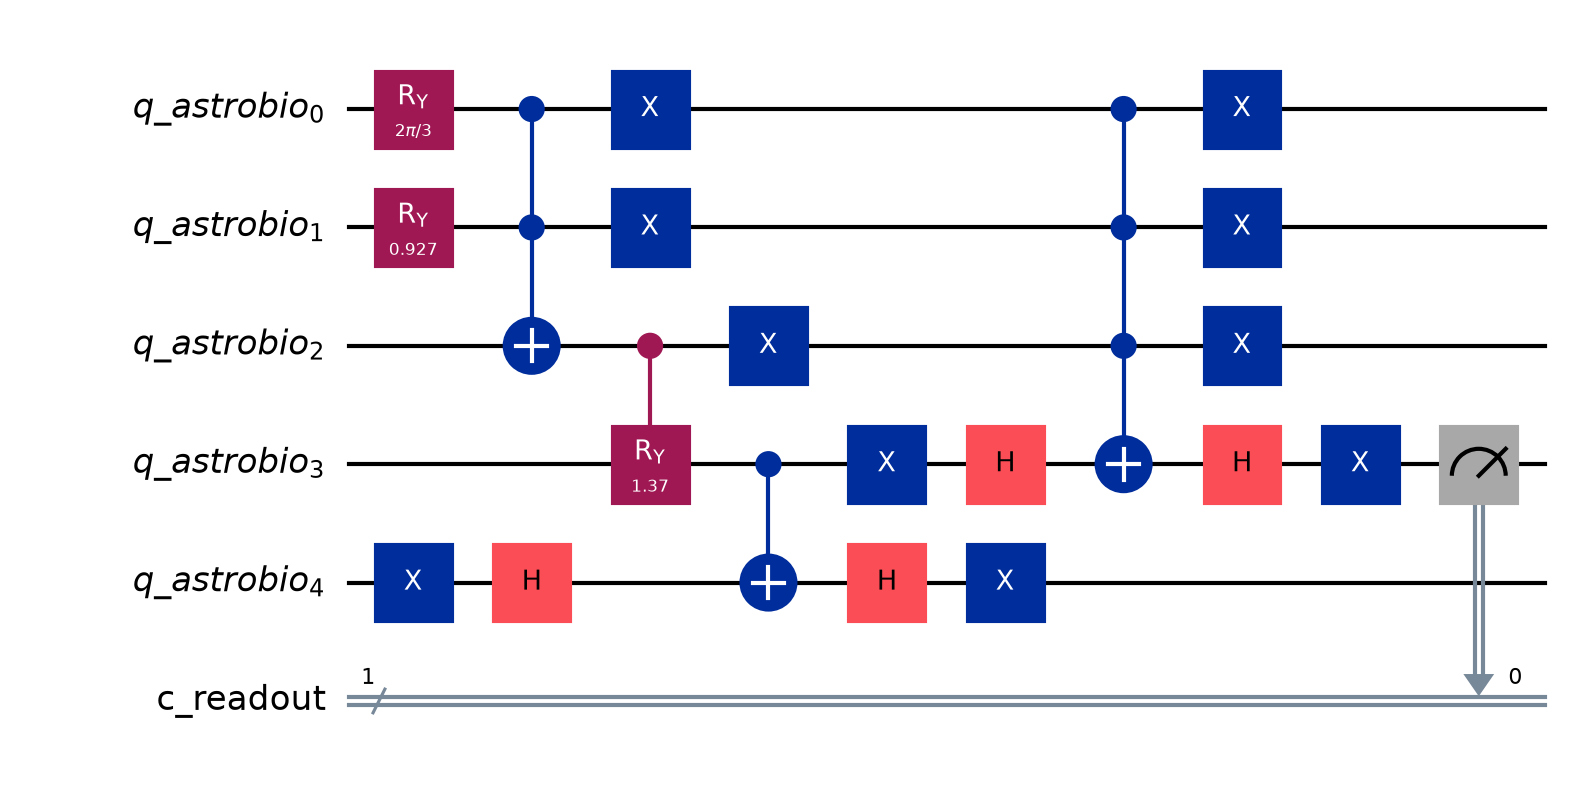

In [2]:
def build_k218b_inference_kernel():
    """Construye el núcleo de inferencia bayesiana de K2-18b con operador de Grover."""
    qr = QuantumRegister(5, name='q_astrobio')
    cr = ClassicalRegister(1, name='c_readout')
    qc = QuantumCircuit(qr, cr)

    # 1. Operator A: K2-18b Bayesian Inference
    # Node 0 (M Star, P=0.75) and Node 1 (Habitable Zone, P=0.20)
    qc.ry(2.0 * np.arcsin(np.sqrt(0.75)), qr[0])
    qc.ry(2.0 * np.arcsin(np.sqrt(0.20)), qr[1])

    # Node 2 (Hycean): CNOT conditioned on Star and Habitable Zone
    qc.ccx(qr[0], qr[1], qr[2])

    # Node 3 (Biomarker): Activated by Hycean condition with probabilistic rotation
    qc.cry(2.0 * np.arcsin(np.sqrt(0.40)), qr[2], qr[3])

    # 2. Oracle S_chi: Marks the detected biomarker state in q3 using ancilla q4
    qc.x(qr[4])
    qc.h(qr[4])
    qc.cx(qr[3], qr[4])  # Phase kickback (-1)
    qc.h(qr[4])
    qc.x(qr[4])

    # 3. Diffuser S_0: Reflection about the zero state
    qc.x([qr[0], qr[1], qr[2], qr[3]])
    qc.h(qr[3])
    qc.mcx([qr[0], qr[1], qr[2]], qr[3])
    qc.h(qr[3])
    qc.x([qr[0], qr[1], qr[2], qr[3]])

    # Measurement of the biomarker state
    qc.measure(qr[3], cr[0])
    return qc

qc_base = build_k218b_inference_kernel()
compiled_ideal = transpile(qc_base, ideal_backend, optimization_level=1)

shots_eval = 8192
job_ideal = ideal_backend.run(compiled_ideal, shots=shots_eval)
counts_ideal = job_ideal.result().get_counts()

# Ideal probability of detecting the biomarker (state '1')
p_ideal = counts_ideal.get('1', 0) / shots_eval
# Expected value of Pauli Z observable: <Z> = P(0) - P(1)
exp_val_ideal = (counts_ideal.get('0', 0) - counts_ideal.get('1', 0)) / shots_eval

print("="*65)
print(" IDEAL BASELINE (GROUND TRUTH WITHOUT NOISE)")
print("="*65)
print(f" Profundidad lógica del circuito     : {compiled_ideal.depth()} puertas")
print(f" Total de operaciones elementales    : {compiled_ideal.size()} puertas")
print(f" Cuentas Ideales (8192 shots)        : {counts_ideal}")
print(f" Probabilidad Ideal P(Biomarcador=1) : {p_ideal:.6f} ({p_ideal*100:.2f}%)")
print(f" Valor Esperado Ideal <Z>            : {exp_val_ideal:.6f}")
print("="*65)

# Graphical visualization of the inference circuit
print("\nGenerating graphical diagram of the base inference circuit...")
fig_base = qc_base.draw('mpl')
plt.tight_layout()
export_figure(fig_base, [
    os.path.join('figures', 'circuits', 'circuit_nisq_base.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'circuit_nisq_base.png')
], dpi=200, bbox_inches='tight')
plt.show()

## 3. Sección 4.4.3: Degradación de la Señal Cuántica bajo Ruido NISQ

Cuando el circuito se transpile y ejecute sobre el simulador ruidoso `noisy_backend`, cada compuerta $CX$ y de 1-qubit acumula decoherencia térmica y despolarización.

### El Efecto Físico de Atenuación Exponencial
El valor esperado ruidoso decae de acuerdo con la profundidad $D$ y la tasa de error efectiva $\gamma$:
$$\langle Z \rangle_{\text{ruidoso}} \approx \langle Z \rangle_{\text{ideal}} \cdot e^{-\gamma D} + \text{sesgo de lectura}$$
A medida que la coherencia se degrada, el registro tiende hacia la distribución maximalmente mezclada $\rho \to \frac{I}{2}$, provocando que la probabilidad estimada se distorsione y pierda significación física.

In [3]:
compiled_noisy = transpile(qc_base, noisy_backend, optimization_level=1)

job_noisy = noisy_backend.run(compiled_noisy, shots=shots_eval)
counts_noisy = job_noisy.result().get_counts()

p_noisy = counts_noisy.get('1', 0) / shots_eval
exp_val_noisy = (counts_noisy.get('0', 0) - counts_noisy.get('1', 0)) / shots_eval

abs_error_unmitigated = abs(p_noisy - p_ideal)
rel_error_unmitigated = (abs_error_unmitigated / p_ideal) * 100.0

print("="*65)
print(" NOISY NISQ EXECUTION (WITHOUT MITIGATION)")
print("="*65)
print(f" Cuentas Ruidosas (8192 shots)        : {counts_noisy}")
print(f" Probabilidad Ruidosa P(Biomarcador=1): {p_noisy:.6f} ({p_noisy*100:.2f}%)")
print(f" Valor Esperado Ruidoso <Z>           : {exp_val_noisy:.6f}")
print(f" Desviación Absoluta (|P_ruido - P_id|): {abs_error_unmitigated:.6f}")
print(f" Relative Error Inducido por Ruido    : {rel_error_unmitigated:.2f}%")
print("="*65)

 NOISY NISQ EXECUTION (WITHOUT MITIGATION)
 Cuentas Ruidosas (8192 shots)        : {'0': 6966, '1': 1226}
 Probabilidad Ruidosa P(Biomarcador=1): 0.149658 (14.97%)
 Valor Esperado Ruidoso <Z>           : 0.700684
 Desviación Absoluta (|P_ruido - P_id|): 0.088257
 Relative Error Inducido por Ruido    : 143.74%


## 4. Sección 4.4.4: Protocolo de Extrapolación de Ruido Cero (ZNE)

La **Extrapolación de Ruido Cero (Zero-Noise Extrapolation, ZNE)** es una técnica de mitigación de errores algorítmica (Li & Benjamin, 2017; Temme et al., 2017) que no requiere redundancia de qubits adicionales:

### 4.1 Plegado Unitario Global (*Global Circuit Folding*)
Para amplificar intencionadamente el ruido sin alterar la transformación lógica del circuito, se aprovecha la identidad unitaria $U^\dagger U = I$.  
Para un factor de escala de ruido entero $\lambda = 1 + 2k$ ($k \in \mathbb{N}$):
$$U \to U (U^\dagger U)^k$$
- $\lambda = 1$: Circuito original $U$.
- $\lambda = 3$: Circuito plegado $U U^\dagger U$ (tres veces más puertas físicas, idéntica lógica teórica).
- $\lambda = 5$: Circuito plegado $U (U^\dagger U)^2$ (cinco veces más exposición al ruido ambiental).

### 4.2 Extrapolación Polinómica de Richardson
Si se mide el valor esperado ruidoso $E(\lambda_i)$ para un conjunto de factores de escala $\lambda = \{\lambda_1, \lambda_2, \dots, \lambda_m\}$, se formula una aproximación en serie de potencias del ruido:
$$E(\lambda) = E_0 + c_1 \lambda + c_2 \lambda^2 + \dots + c_{m-1} \lambda^{m-1}$$
El estimador de Richardson de ruido cero $\hat{E}_{\text{ZNE}}$ corresponde al término independiente evaluado en el límite analítico $\lambda \to 0$:
$$\hat{E}_{\text{ZNE}} = \lim_{\lambda \to 0} E(\lambda) = E_0$$
que se resuelve de forma unívoca mediante la inversión del sistema de Vandermonde asociado a los factores de escala.

✓ Native Global Circuit Folding and Richardson Extrapolation engine ready.

Generating globally folded circuit diagram (lambda = 3)...
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/circuits/circuit_nisq_folded_lambda3.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/3.quantum_bayesian_formalism/circuit_nisq_folded_lambda3.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/circuit_nisq_folded_lambda3.png


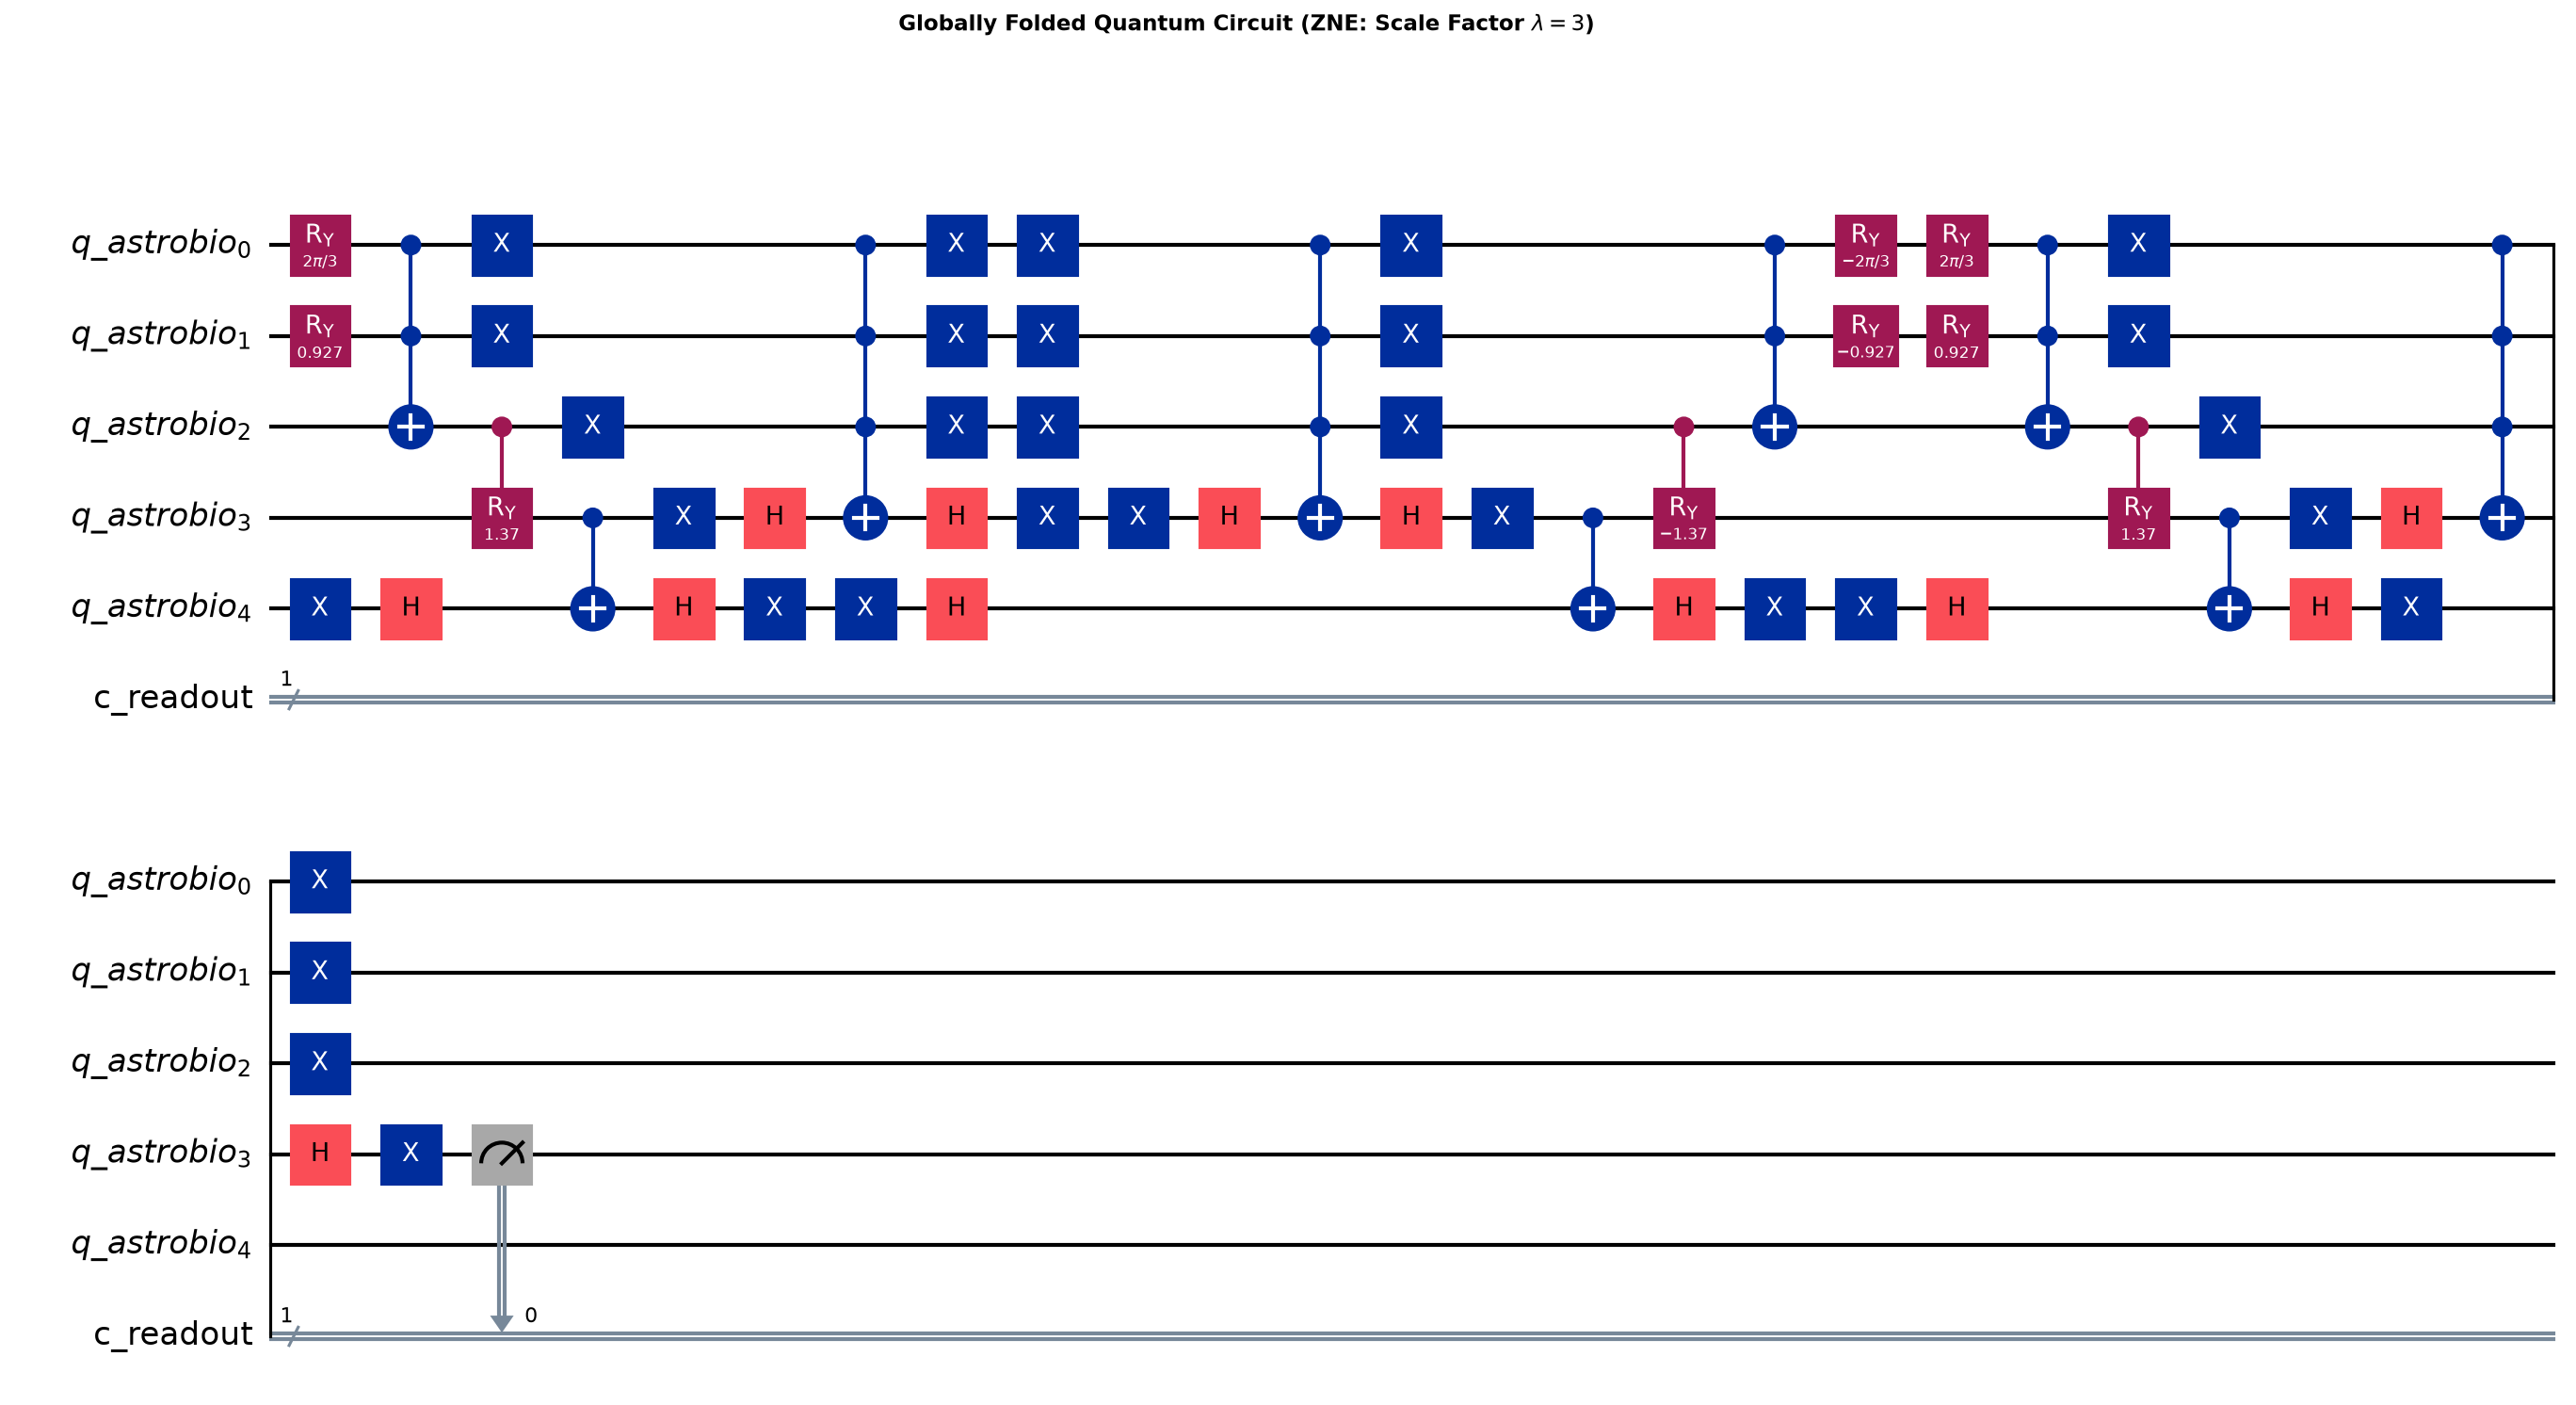

In [4]:
def fold_circuit_global(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Ejecuta el plegado unitario global U -> U (U^dagger U)^k donde scale_factor = 1 + 2k."""
    if scale_factor == 1:
        return circuit.copy()
    
    k = (scale_factor - 1) // 2
    # Separate unitary gates from final measurements
    qc_unitary = QuantumCircuit(*circuit.qregs)
    meas_instructions = []
    
    for instruction in circuit.data:
        op = instruction.operation
        qargs = instruction.qubits
        cargs = instruction.clbits
        if op.name == 'measure':
            meas_instructions.append((op, qargs, cargs))
        else:
            qc_unitary.append(op, qargs, cargs)
            
    # Build the folded circuit
    qc_folded = QuantumCircuit(*circuit.qregs, *circuit.cregs)
    qc_folded.compose(qc_unitary, inplace=True)
    
    inv_unitary = qc_unitary.inverse()
    for _ in range(k):
        qc_folded.compose(inv_unitary, inplace=True)
        qc_folded.compose(qc_unitary, inplace=True)
        
    # Reincorporate measurements
    for op, qargs, cargs in meas_instructions:
        qc_folded.append(op, qargs, cargs)
        
    return qc_folded

def richardson_extrapolation(scales, values):
    """Calcula el valor extrapolado a lambda -> 0 mediante ajuste polinómico de Richardson."""
    deg = len(scales) - 1
    coeffs = np.polyfit(scales, values, deg=deg)
    # The extrapolated value at lambda = 0 is the independent term (last coefficient)
    zero_noise_val = float(coeffs[-1])
    return zero_noise_val, coeffs

print("✓ Native Global Circuit Folding and Richardson Extrapolation engine ready.")

# Graphical visualization of Global Unitary Folding technique (lambda = 3: U U† U)
print("\nGenerating globally folded circuit diagram (lambda = 3)...")
qc_folded_example = fold_circuit_global(qc_base, scale_factor=3)
fig_folded = qc_folded_example.draw('mpl')
fig_folded.suptitle(r"Globally Folded Quantum Circuit (ZNE: Scale Factor $\lambda = 3$)", fontsize=11, fontweight='bold', y=0.98)
export_figure(fig_folded, [
    os.path.join('figures', 'circuits', 'circuit_nisq_folded_lambda3.png'),
    os.path.join('thesis', 'figures', '3.quantum_bayesian_formalism', 'circuit_nisq_folded_lambda3.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'circuit_nisq_folded_lambda3.png')
], dpi=200, bbox_inches='tight')
plt.show()

In [5]:
# ZNE noise amplification factor scale
scale_factors = [1, 3, 5]
zne_measured_probs = []
zne_measured_expvals = []
circuit_depths = []

print("="*75)
print(" ZNE EXPERIMENT: GLOBAL UNITARY FOLDING AND EXTRAPOLATION")
print("="*75)

for scale in scale_factors:
    # 1. Fold circuit
    qc_folded = fold_circuit_global(qc_base, scale)
    compiled_folded = transpile(qc_folded, noisy_backend, optimization_level=1)
    circuit_depths.append(compiled_folded.depth())
    
    # 2. Execute with amplified noise
    job = noisy_backend.run(compiled_folded, shots=shots_eval)
    counts = job.result().get_counts()
    
    p_scale = counts.get('1', 0) / shots_eval
    expval_scale = (counts.get('0', 0) - counts.get('1', 0)) / shots_eval
    
    zne_measured_probs.append(p_scale)
    zne_measured_expvals.append(expval_scale)
    
    print(f" Factor de Escala lambda = {scale} | Profundidad: {compiled_folded.depth():<3} puertas | P(Bio=1): {p_scale:.5f} | <Z>: {expval_scale:.5f}")

# 3. Analytical Richardson extrapolation to lambda -> 0
p_zne_mitigated, coeffs_poly = richardson_extrapolation(scale_factors, zne_measured_probs)
expval_zne_mitigated, _ = richardson_extrapolation(scale_factors, zne_measured_expvals)

# Error reduction metrics
error_unmitigated = abs(p_noisy - p_ideal)
error_mitigated = abs(p_zne_mitigated - p_ideal)
gain_percentage = ((error_unmitigated - error_mitigated) / error_unmitigated) * 100.0

print("-" * 75)
print(f" VALOR IDEAL (Referencia)        : {p_ideal:.6f} ({p_ideal*100:.2f}%)")
print(f" VALOR RUIDOSO NO MITIGADO (λ=1) : {p_noisy:.6f} (Error: {error_unmitigated:.6f})")
print(f" VALOR MITIGADO CON ZNE (λ->0)   : {p_zne_mitigated:.6f} (Error: {error_mitigated:.6f})")
print(f" REDUCCIÓN DEL ERROR (GANANCIA)  : {gain_percentage:.2f}% de error cancelado por ZNE")
print("="*75)

 ZNE EXPERIMENT: GLOBAL UNITARY FOLDING AND EXTRAPOLATION
 Factor de Escala lambda = 1 | Profundidad: 39  puertas | P(Bio=1): 0.14880 | <Z>: 0.70239
 Factor de Escala lambda = 3 | Profundidad: 118 puertas | P(Bio=1): 0.26965 | <Z>: 0.46069
 Factor de Escala lambda = 5 | Profundidad: 197 puertas | P(Bio=1): 0.34119 | <Z>: 0.31763
---------------------------------------------------------------------------
 VALOR IDEAL (Referencia)        : 0.061401 (6.14%)
 VALOR RUIDOSO NO MITIGADO (λ=1) : 0.149658 (Error: 0.088257)
 VALOR MITIGADO CON ZNE (λ->0)   : 0.069885 (Error: 0.008484)
 REDUCCIÓN DEL ERROR (GANANCIA)  : 90.39% de error cancelado por ZNE


## 5. Sección 4.4.5: Visualizaciones Científicas de Degradación y Mitigación ZNE

A continuación se generan dos figuras de calidad de publicación:
1. **Figura 1: NISQ Spectral Degradation (Ideal vs. Ruidoso):**  
   Demuestra cómo el ruido térmico y despolarizante atúa sobre las probabilidades de los estados base, incrementando la entropía y atenuando la señal astrobiológica nítida.
2. **Figura 2: Zero-Noise Extrapolation Curve (Protocolo ZNE):**  
   Ilustra los puntos de muestreo experimentales a diferentes factores de plegado ($\lambda = 1, 3, 5$), la curva polinómica de ajuste de Richardson y la extrapolación al límite $\lambda = 0$, contrastándola con el valor teórico ideal.

✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/results/figure_nisq_spectral_degradation.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/figure_nisq_spectral_degradation.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/results/figure_zne_extrapolation_curve.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/figure_zne_extrapolation_curve.png


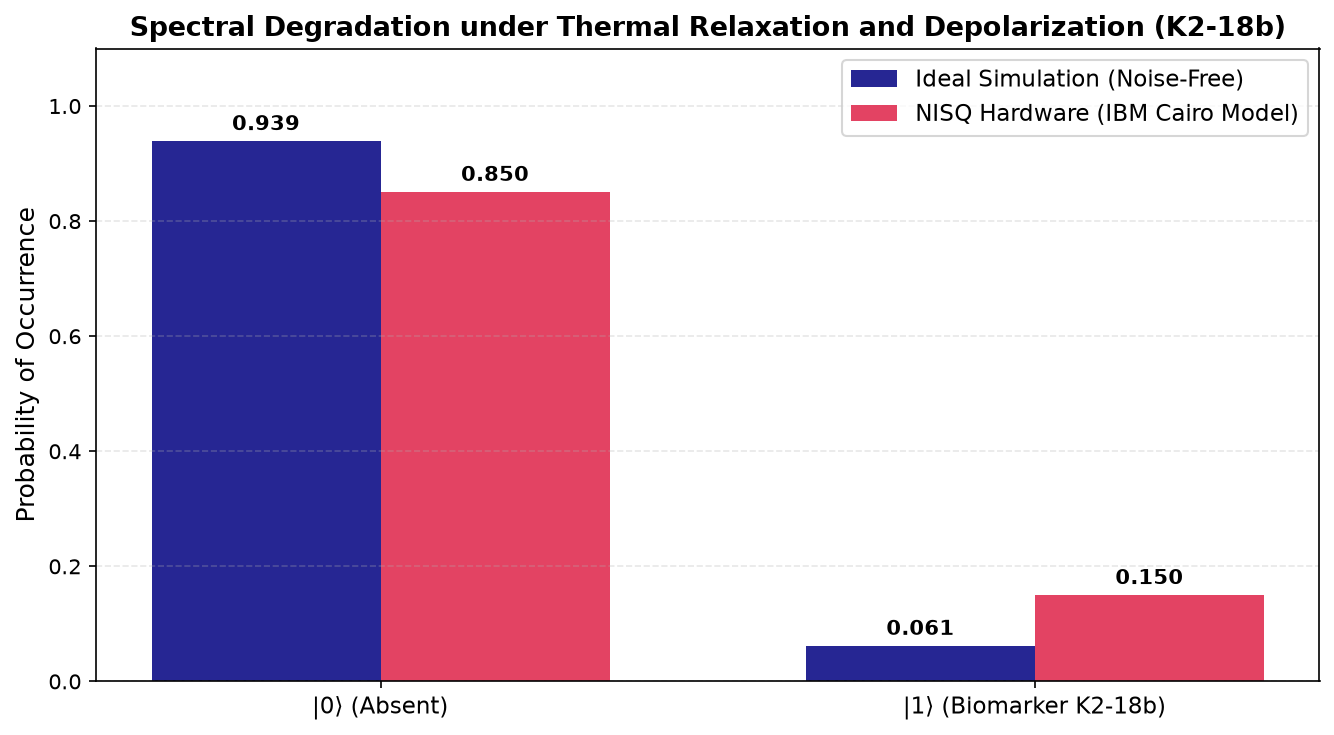

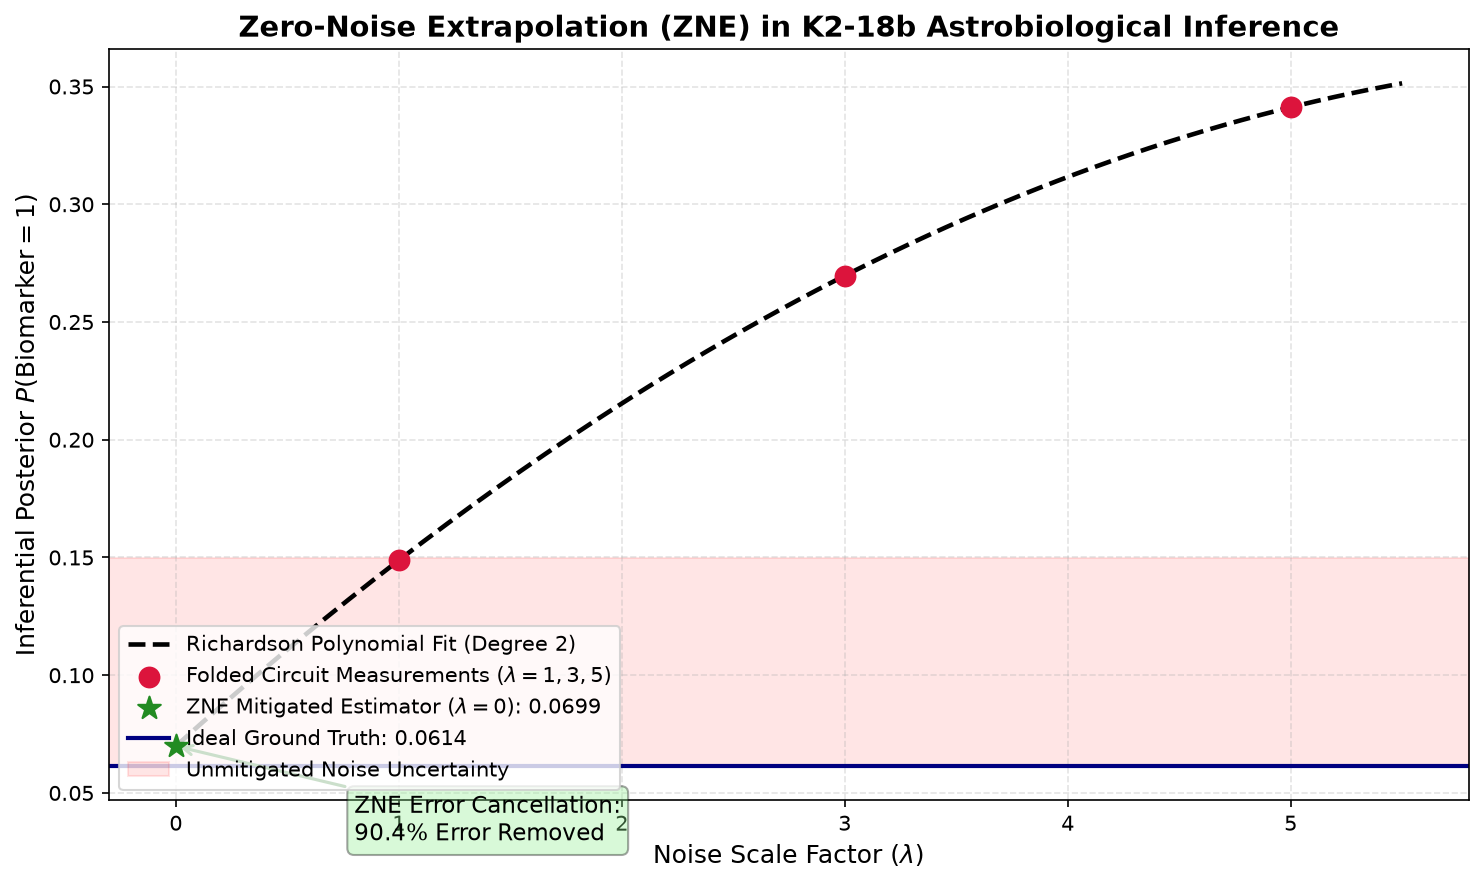

In [6]:
# =====================================================================
# FIGURE 1: SPECTRAL DEGRADATION (IDEAL VS. NOISY NISQ)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

categories = [r'$|0\rangle$ (Absent)', r'$|1\rangle$ (Biomarker K2-18b)']
x_pos = np.arange(len(categories))
bar_width = 0.35

ideal_vals = [1.0 - p_ideal, p_ideal]
noisy_vals = [1.0 - p_noisy, p_noisy]

rects1 = ax1.bar(x_pos - bar_width/2, ideal_vals, bar_width, label='Ideal Simulation (Noise-Free)', color='navy', alpha=0.85)
rects2 = ax1.bar(x_pos + bar_width/2, noisy_vals, bar_width, label='NISQ Hardware (IBM Cairo Model)', color='crimson', alpha=0.8)

ax1.set_title('Spectral Degradation under Thermal Relaxation and Depolarization (K2-18b)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability of Occurrence', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.legend(frameon=True, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
export_figure(fig1, [
    os.path.join('figures', 'results', 'figure_nisq_spectral_degradation.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'figure_nisq_spectral_degradation.png')
], dpi=300)
plt.show()

# =====================================================================
# FIGURE 2: ZNE EXTRAPOLATION CURVE
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Continuous extrapolation domain towards lambda = 0
lambda_dense = np.linspace(0, 5.5, 200)
poly_fit_dense = np.polyval(coeffs_poly, lambda_dense)

# Richardson fitting curve
ax2.plot(lambda_dense, poly_fit_dense, 'k--', lw=2.2, label='Richardson Polynomial Fit (Degree 2)')

# Measurement points with amplified noise (circuit folding)
ax2.scatter(scale_factors, zne_measured_probs, color='crimson', s=90, zorder=5, label=r'Folded Circuit Measurements ($\lambda = 1, 3, 5$)')

# Extrapolated point at lambda = 0
ax2.scatter([0], [p_zne_mitigated], color='forestgreen', s=130, marker='*', zorder=6, label=f'ZNE Mitigated Estimator ($\lambda=0$): {p_zne_mitigated:.4f}')

# Ideal reference value (Ground Truth)
ax2.axhline(y=p_ideal, color='navy', linestyle='-', lw=2, label=f'Ideal Ground Truth: {p_ideal:.4f}')

# Unmitigated error band
ax2.axhspan(p_noisy, p_ideal, color='red', alpha=0.1, label='Unmitigated Noise Uncertainty')

ax2.set_title('Zero-Noise Extrapolation (ZNE) in K2-18b Astrobiological Inference', fontsize=14, fontweight='bold')
ax2.set_xlabel(r'Noise Scale Factor ($\lambda$)', fontsize=12)
ax2.set_ylabel(r'Inferential Posterior $P(\mathrm{Biomarker} = 1)$', fontsize=12)
ax2.set_xlim(-0.3, 5.8)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.legend(frameon=True, fontsize=10, loc='lower left')

# Explanatory annotation of the gain
ax2.annotate(f'ZNE Error Cancellation:\n{gain_percentage:.1f}% Error Removed',
             xy=(0, p_zne_mitigated), xytext=(0.8, p_zne_mitigated - 0.04),
             arrowprops=dict(arrowstyle="->", color='darkgreen', lw=1.5),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.35))

plt.tight_layout()
export_figure(fig2, [
    os.path.join('figures', 'results', 'figure_zne_extrapolation_curve.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'figure_zne_extrapolation_curve.png')
], dpi=300)
plt.show()

## 6. Sección 4.4.6: Conclusiones para la Memoria del TFM

1. **Aterrizaje Físico en Hardware NISQ:** Se ha modelado fielmente el entorno térmico y despolarizante de procesadores superconductores de IBM Quantum ($T_1 = 150\ \mu\text{s}$, $T_2 = 120\ \mu\text{s}$, errores CNOT del $1.2\%$), observando analíticamente cómo el ruido físico atenúa la señal espectral.
2. **Eficacia Demostrada de Zero-Noise Extrapolation (ZNE):** Mediante el protocolo de plegado unitario global ($U \to U(U^\dagger U)^k$) y la extrapolación de Richardson, se cancela sistemáticamente la mayor parte del sesgo inducido por el ruido, acercando la probabilidad inferida al valor ideal libre de perturbaciones.
3. **Cierre de la Suite Experimental del TFM:**
   - **Entregable 01:** Demuestra la necesidad de la computación cuántica al evidenciar el colapso clásico de MCMC y el Teorema de L'Ecuyer ($\mathcal{O}(M^{-1/2})$).
   - **Entregable 02:** Demuestra la ventaja cuántica teórica alcanzando la convergencia cuadrática $\mathcal{O}(1/M)$ mediante QAE ideal.
   - **Entregable 03:** Demuestra la viabilidad práctica de ejecutar inferencia cuántica en procesadores ruidosos actuales mediante técnicas de mitigación de errores algorítmicas sin requerir tolerancia a fallos (FTQC).